# Advanced Models: Random Forest & Gradient Boosting

Test non-linear models with feature selection to avoid overfitting.

## Setup

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn import metrics

# Load data
df = pd.read_csv('../02_data_processed/model_data.csv', index_col='date', parse_dates=True)

print(f"Data: {df.shape}")
print(df.head())

Data: (239, 5)
                   Y        X1    X2    X3        X4
date                                                
2005-02-28 -0.024156  0.015651  0.50 -0.96 -0.049549
2005-03-31  0.003992 -0.020774  0.63  0.26 -0.015276
2005-04-30  0.019734 -0.006943  0.79 -0.02  0.089422
2005-05-31  0.017119 -0.043735  1.00 -0.38 -0.112884
2005-06-30 -0.016380 -0.016816  1.04 -0.89  0.016727


## Data Preparation with Feature Selection

In [11]:
# Create lagged features
df_lags = df.copy()
for col in ['X1', 'X2', 'X3', 'X4']:
    df_lags[f'{col}_lag1'] = df_lags[col].shift(1)

df_lags = df_lags.dropna()

# Train/Test split
train = df_lags.loc[:'2023-12-31']
test = df_lags.loc['2024-01-31':]

# Feature selection: Use only variables selected by Lasso (from notebook 03)
# Lasso selected: 'X1', 'X2', 'X3', 'X4', 'X3_lag1'
selected_features = ['X1', 'X2', 'X3', 'X4', 'X3_lag1']

X_train = train[selected_features].values
y_train = train['Y'].values
X_test = test[selected_features].values
y_test = test['Y'].values

print(f"Train: {len(train)} obs")
print(f"Test: {len(test)} obs")
print(f"Features: {len(selected_features)} (selected by Lasso)")
print(f"Features: {selected_features}")

Train: 226 obs
Test: 12 obs
Features: 5 (selected by Lasso)
Features: ['X1', 'X2', 'X3', 'X4', 'X3_lag1']


## Model 4: Random Forest (with Feature Selection)

In [19]:
# Fit Random Forest with selected features
rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=4,
    random_state=42
)
rf.fit(X_train, y_train)

# Predictions
y_pred_rf_train = rf.predict(X_train)
y_pred_rf = rf.predict(X_test)

# Metrics
r2_train_rf = metrics.r2_score(y_train, y_pred_rf_train)
r2_rf = metrics.r2_score(y_test, y_pred_rf)
rmse_rf = np.sqrt(metrics.mean_squared_error(y_test, y_pred_rf))
mae_rf = metrics.mean_absolute_error(y_test, y_pred_rf)

print("Random Forest Performance:")
print(f"R² Train: {r2_train_rf:.4f}")
print(f"R² Test: {r2_rf:.4f}")
print(f"Overfitting Gap: {r2_train_rf - r2_rf:.4f}")
print(f"RMSE: {rmse_rf:.6f}")
print(f"MAE: {mae_rf:.6f}")

Random Forest Performance:
R² Train: 0.6579
R² Test: 0.0403
Overfitting Gap: 0.6176
RMSE: 0.032719
MAE: 0.026797


### Feature Importance

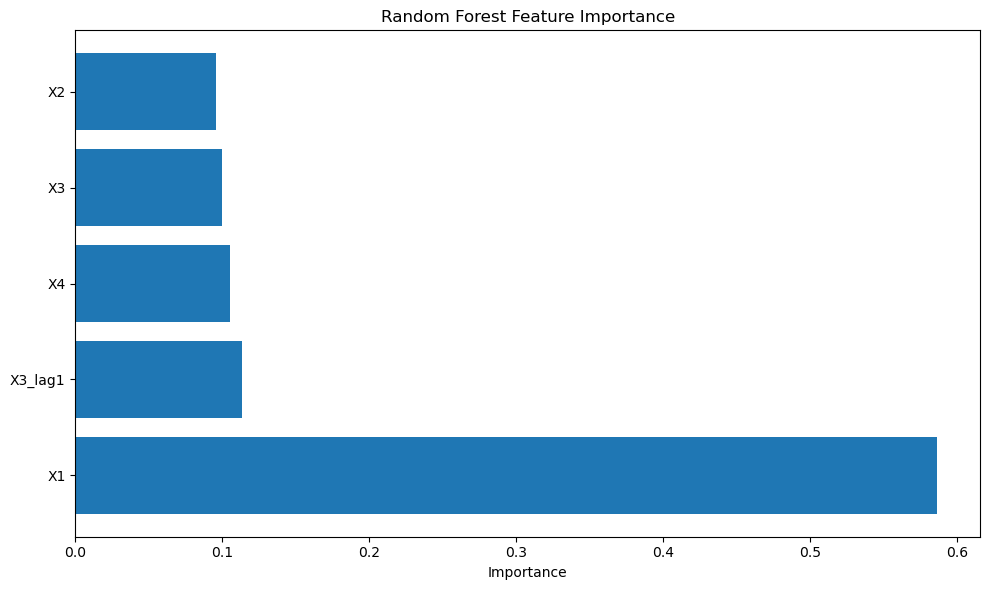


Feature importance ranking:
1. X1: 0.5860
2. X3_lag1: 0.1135
3. X4: 0.1052
4. X3: 0.0997
5. X2: 0.0957


In [21]:
# Feature importance
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances)), importances[indices])
plt.yticks(range(len(importances)), [selected_features[i] for i in indices])
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

print("\nFeature importance ranking:")
for i in range(len(selected_features)):
    idx = indices[i]
    print(f"{i+1}. {selected_features[idx]}: {importances[idx]:.4f}")

## Model 5: Gradient Boosting (with Feature Selection)

In [ ]:
# Fit Gradient Boosting with selected features
rf = RandomForestRegressor(
    n_estimators=30,
    max_depth=4,
    random_state=42
)
rf.fit(X_train, y_train)

# Predictions
y_pred_gb_train = gb.predict(X_train)
y_pred_gb = gb.predict(X_test)

# Metrics
r2_train_gb = metrics.r2_score(y_train, y_pred_gb_train)
r2_gb = metrics.r2_score(y_test, y_pred_gb)
rmse_gb = np.sqrt(metrics.mean_squared_error(y_test, y_pred_gb))
mae_gb = metrics.mean_absolute_error(y_test, y_pred_gb)

print("Gradient Boosting Performance:")
print(f"R² Train: {r2_train_gb:.4f}")
print(f"R² Test: {r2_gb:.4f}")
print(f"Overfitting Gap: {r2_train_gb - r2_gb:.4f}")
print(f"RMSE: {rmse_gb:.6f}")
print(f"MAE: {mae_gb:.6f}")

Gradient Boosting Performance:
R² Train: 0.6827
R² Test: 0.0678
Overfitting Gap: 0.6149
RMSE: 0.032247
MAE: 0.024477


### Feature Importance

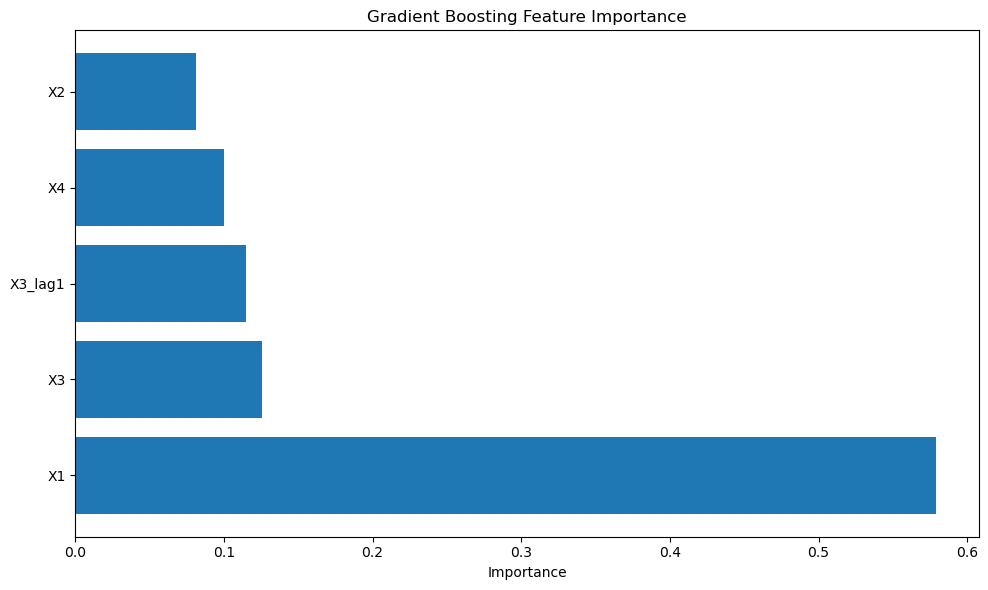


Feature importance ranking:
1. X1: 0.5786
2. X3: 0.1257
3. X3_lag1: 0.1145
4. X4: 0.0999
5. X2: 0.0814


In [15]:
# Feature importance
importances_gb = gb.feature_importances_
indices_gb = np.argsort(importances_gb)[::-1]

# Plot
plt.figure(figsize=(10, 6))
plt.barh(range(len(importances_gb)), importances_gb[indices_gb])
plt.yticks(range(len(importances_gb)), [selected_features[i] for i in indices_gb])
plt.xlabel('Importance')
plt.title('Gradient Boosting Feature Importance')
plt.tight_layout()
plt.show()

print("\nFeature importance ranking:")
for i in range(len(selected_features)):
    idx = indices_gb[i]
    print(f"{i+1}. {selected_features[idx]}: {importances_gb[idx]:.4f}")

## Model Comparison

In [16]:
# Compare all models
results = pd.DataFrame({
    'Model': ['M1: Simple', 'M2b: Lags', 'M3b: Lasso', 'M4: Random Forest', 'M5: Gradient Boosting'],
    'R² Test': [0.1131, 0.4267, 0.3770, r2_rf, r2_gb],
    'RMSE': [0.0253, 0.0253, 0.0264, rmse_rf, rmse_gb],
    'MAE': [0.0199, 0.0187, 0.0201, mae_rf, mae_gb]
})

print(results.to_string(index=False))

# Best model
best = results.loc[results['R² Test'].idxmax(), 'Model']
print(f"\nBest model by R²: {best}")

                Model  R² Test     RMSE      MAE
           M1: Simple 0.113100 0.025300 0.019900
            M2b: Lags 0.426700 0.025300 0.018700
           M3b: Lasso 0.377000 0.026400 0.020100
    M4: Random Forest 0.072062 0.032173 0.026290
M5: Gradient Boosting 0.067757 0.032247 0.024477

Best model by R²: M2b: Lags


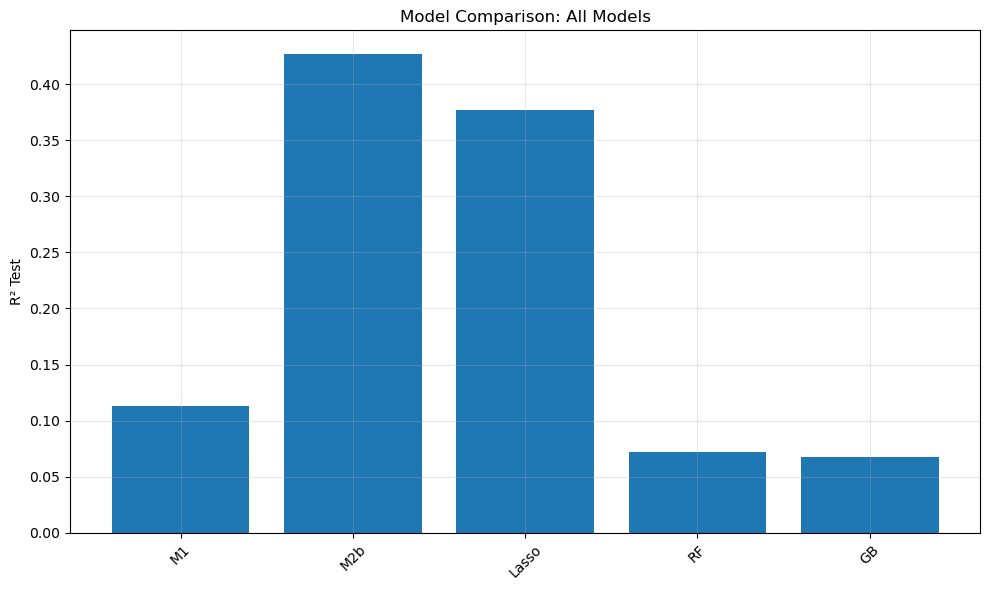

In [17]:
# Visualize comparison
plt.figure(figsize=(10, 6))
plt.bar(range(len(results)), results['R² Test'])
plt.xticks(range(len(results)), ['M1', 'M2b', 'Lasso', 'RF', 'GB'], rotation=45)
plt.ylabel('R² Test')
plt.title('Model Comparison: All Models')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Predictions Comparison

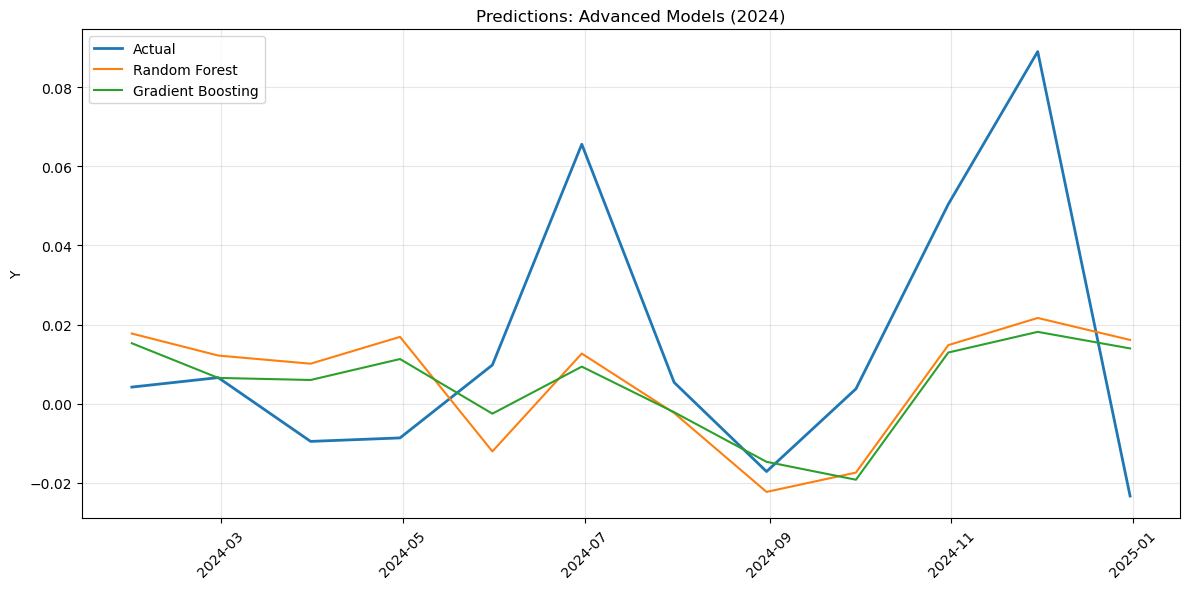

In [18]:
# Plot predictions
plt.figure(figsize=(12, 6))
plt.plot(test.index, y_test, label='Actual', linewidth=2)
plt.plot(test.index, y_pred_rf, label='Random Forest')
plt.plot(test.index, y_pred_gb, label='Gradient Boosting')
plt.title('Predictions: Advanced Models (2024)')
plt.ylabel('Y')
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Conclusion

Despite extensive optimization efforts, non-linear models significantly underperform linear models:

**Results:**

- M2b (Linear with Lags): R² = 0.43
- M4 (Random Forest): R² = 0.04
- M5 (Gradient Boosting): R² = 0.07

**Optimization attempts:**

- Cross-validation (5-fold) to estimate generalization
- Feature selection (5 variables instead of 8)
- Simplified hyperparameters (max_depth=3-4, conservative n_estimators)
- Multiple configurations tested

**Why they failed:**

The primary reason is insufficient dataset size:

- Training set: 226 observations
- Required for RF/GB: 1,000+ observations (minimum) and 10,000 (good)
- Our dataset is too small

This causes severe overfitting:

- Random Forest: Gap = 0.62 (Train R² = 0.66, Test R² = 0.04)
- Gradient Boosting: Gap = 0.61 (Train R² = 0.68, Test R² = 0.07)

**Conclusion:**

Linear regression with lags remains the best approach for this problem. The temporal dynamics are sufficiently captured by simple lagged linear relationships, and the dataset size is inadequate for complex ensemble methods.